In [105]:
import pandas as pd
import numpy as np

In [106]:
df1=pd.read_csv("submission.csv")
test=pd.read_csv("test.csv")
train=pd.read_csv("train.csv")

In [107]:
df1.head(2)

,ID,food_waste_kg
0,0,28.946465
1,1,51.549053


In [108]:
train.head(2)

,ID,date,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,food_waste_kg
0,0,2022-12-19,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy,28.946465
1,1,2023-11-21,244,15,10.317872,64.430475,1,0,42.311779,NaN,MeAt,51.549053


In [109]:
test.head(2)

,ID,date,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category
0,0,2022-12-19,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy
1,1,2023-11-21,244,15,10.317872,64.430475,1,0,42.311779,NaN,MeAt


In [110]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                911 non-null    int64  
 1   date              911 non-null    object 
 2   meals_served      911 non-null    int64  
 3   kitchen_staff     911 non-null    int64  
 4   temperature_C     911 non-null    float64
 5   humidity_percent  911 non-null    float64
 6   day_of_week       911 non-null    int64  
 7   special_event     911 non-null    int64  
 8   past_waste_kg     911 non-null    float64
 9   staff_experience  747 non-null    object 
 10  waste_category    911 non-null    object 
 11  food_waste_kg     911 non-null    float64
dtypes: float64(4), int64(5), object(3)
memory usage: 85.5+ KB


In [111]:
train['staff_experience'] = train['staff_experience'].fillna(train['staff_experience'].mode()[0])
test['staff_experience'] = test['staff_experience'].fillna(test['staff_experience'].mode()[0])

In [112]:
print(train.isnull().sum())

ID                  0
date                0
meals_served        0
kitchen_staff       0
temperature_C       0
humidity_percent    0
day_of_week         0
special_event       0
past_waste_kg       0
staff_experience    0
waste_category      0
food_waste_kg       0
dtype: int64


In [113]:
train.head(2)

,ID,date,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,food_waste_kg
0,0,2022-12-19,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy,28.946465
1,1,2023-11-21,244,15,10.317872,64.430475,1,0,42.311779,Beginner,MeAt,51.549053


Drops unused columns

In [114]:
train = train.drop([ 'ID','date'], axis=1)
test = test.drop(['ID','date'], axis=1)

In [115]:
train.sample(2)

,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,food_waste_kg
824,470,8,28.983608,73.542988,6,1,24.824262,EXPERT,dairy,66.951662
115,256,10,18.148137,57.865994,0,0,44.269478,Beginner,MEAT,53.019181


In [116]:
test.sample(2)

,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category
901,338,9,33.757819,37.132463,5,0,22.121685,EXPERT,MeAt
232,180,7,31.434002,64.030247,0,0,11.105974,Intermediate,MEAT


In [117]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np


X = train.drop('food_waste_kg', axis=1)
y = train['food_waste_kg']


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), [7,8])

    ] , remainder='passthrough'
)


X_processed = preprocessor.fit_transform(X)
test_processed = preprocessor.transform(test)


X_train, X_val, y_train, y_val = train_test_split(X_processed, y, test_size=0.2, random_state=42)


model = RandomForestRegressor(n_estimators=100, random_state=42)


model.fit(X_train, y_train)


y_pred = model.predict(test_processed)

In [118]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


mse_test = mean_squared_error(df1['food_waste_kg'], y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(df1['food_waste_kg'], y_pred)

print(f"Mean Squared Error (Test): {mse_test:.4f}")
print(f"Root Mean Squared Error (Test): {rmse_test:.4f}")
print(f"R-squared (Test): {r2_test:.4f}")

Mean Squared Error (Test): 19.6221
Root Mean Squared Error (Test): 4.4297
R-squared (Test): 0.9748


In [119]:
from sklearn.ensemble import GradientBoostingRegressor


gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(test_processed)

In [120]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


mse_gb = mean_squared_error(df1['food_waste_kg'], y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(df1['food_waste_kg'], y_pred_gb)

print(f"Gradient Boosting Mean Squared Error (Test): {mse_gb:.4f}")
print(f"Gradient Boosting Root Mean Squared Error (Test): {rmse_gb:.4f}")
print(f"Gradient Boosting R-squared (Test): {r2_gb:.4f}")

Gradient Boosting Mean Squared Error (Test): 23.9262
Gradient Boosting Root Mean Squared Error (Test): 4.8914
Gradient Boosting R-squared (Test): 0.9693


### Decision Tree Regressor

In [121]:
from sklearn.tree import DecisionTreeRegressor


dt_model = DecisionTreeRegressor(random_state=42)


dt_model.fit(X_train, y_train)


y_pred_dt = dt_model.predict(test_processed)


mse_dt = mean_squared_error(df1['food_waste_kg'], y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(df1['food_waste_kg'], y_pred_dt)

print(f"Decision Tree Mean Squared Error (Test): {mse_dt:.4f}")
print(f"Decision Tree Root Mean Squared Error (Test): {rmse_dt:.4f}")
print(f"Decision Tree R-squared (Test): {r2_dt:.4f}")

Decision Tree Mean Squared Error (Test): 24.1766
Decision Tree Root Mean Squared Error (Test): 4.9170
Decision Tree R-squared (Test): 0.9690


### Linear Regression

In [122]:
from sklearn.linear_model import LinearRegression


lr_model = LinearRegression()


lr_model.fit(X_train, y_train)


y_pred_lr = lr_model.predict(test_processed)


mse_lr = mean_squared_error(df1['food_waste_kg'], y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(df1['food_waste_kg'], y_pred_lr)

print(f"Linear Regression Mean Squared Error (Test): {mse_lr:.4f}")
print(f"Linear Regression Root Mean Squared Error (Test): {rmse_lr:.4f}")
print(f"Linear Regression R-squared (Test): {r2_lr:.4f}")

Linear Regression Mean Squared Error (Test): 121.8613
Linear Regression Root Mean Squared Error (Test): 11.0391
Linear Regression R-squared (Test): 0.8437


### Neural Network (Multi-layer Perceptron Regressor)

In [123]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_processed_scaled = scaler.transform(test_processed)


mlp_model = MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=500, random_state=42)


mlp_model.fit(X_train_scaled, y_train)


y_pred_mlp = mlp_model.predict(X_test_processed_scaled)


mse_mlp = mean_squared_error(df1['food_waste_kg'], y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(df1['food_waste_kg'], y_pred_mlp)

print(f"Neural Network (MLP) Mean Squared Error (Test): {mse_mlp:.4f}")
print(f"Neural Network (MLP) Root Mean Squared Error (Test): {rmse_mlp:.4f}")
print(f"Neural Network (MLP) R-squared (Test): {r2_mlp:.4f}")

Neural Network (MLP) Mean Squared Error (Test): 94.8141
Neural Network (MLP) Root Mean Squared Error (Test): 9.7373
Neural Network (MLP) R-squared (Test): 0.8784


c:\Users\sudip\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [124]:
import pandas as pd


results = {
    'Model': ['Random Forest', 'Gradient Boosting', 'Decision Tree', 'Linear Regression', 'Neural Network (MLP)'],
    'MSE': [mse_test, mse_gb, mse_dt, mse_lr, mse_mlp],
    'RMSE': [rmse_test, rmse_gb, rmse_dt, rmse_lr, rmse_mlp],
    'R-squared': [r2_test, r2_gb, r2_dt, r2_lr, r2_mlp]
}


results_df = pd.DataFrame(results)


results_df = results_df.sort_values(by='R-squared', ascending=False)


display(results_df)

,Model,MSE,RMSE,R-squared
0,Random Forest,19.622076,4.429681,0.974826
1,Gradient Boosting,23.926238,4.891445,0.969305
2,Decision Tree,24.176648,4.916975,0.968983
4,Neural Network (MLP),94.814099,9.737253,0.878361
3,Linear Regression,121.861296,11.039080,0.843662


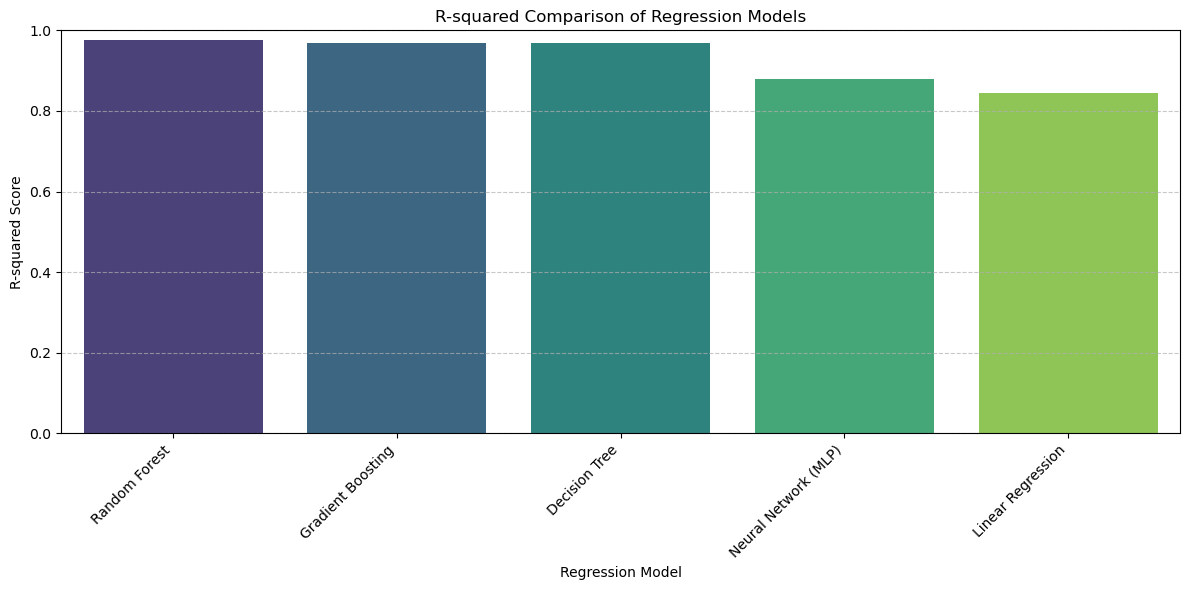

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R-squared', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title('R-squared Comparison of Regression Models')
plt.xlabel('Regression Model')
plt.ylabel('R-squared Score')
plt.ylim(0, 1) # R-squared typically ranges from 0 to 1
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()